In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("StudentsPerformance.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
print("Shape of Dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nInformation:")
df.info()

Shape of Dataset: (1000, 8)

Columns:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (1000, 8)


In [10]:
print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nMode")
print(df.mode().iloc[0])

Mean
math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

Median
math score       66.0
reading score    70.0
writing score    69.0
dtype: float64

Mode
gender                               female
race/ethnicity                      group C
parental level of education    some college
lunch                              standard
test preparation course                none
math score                               65
reading score                            72
writing score                            74
Name: 0, dtype: object


In [11]:
print("Variance")
print(df.var(numeric_only=True))

print("\nStandard Deviation")
print(df.std(numeric_only=True))

Variance
math score       229.918998
reading score    213.165605
writing score    230.907992
dtype: float64

Standard Deviation
math score       15.163080
reading score    14.600192
writing score    15.195657
dtype: float64


In [12]:
correlation = df.corr(numeric_only=True)

print(correlation)

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


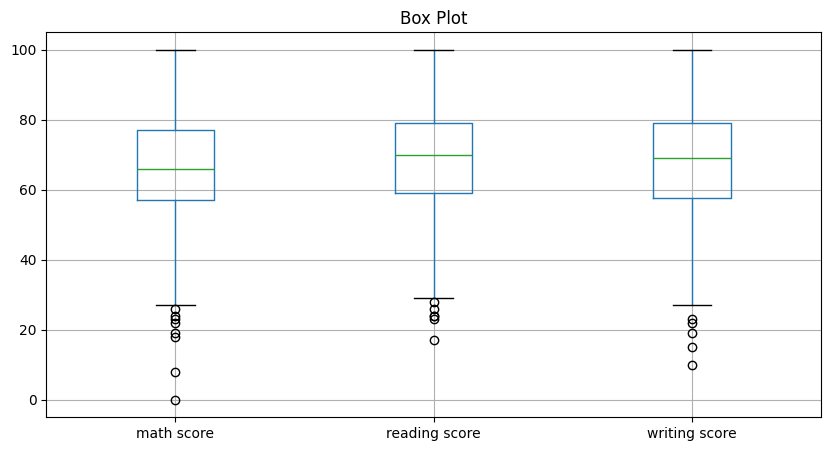

In [13]:
numeric_columns = df.select_dtypes(include=np.number)

numeric_columns.boxplot(figsize=(10,5))

plt.title("Box Plot")
plt.show()

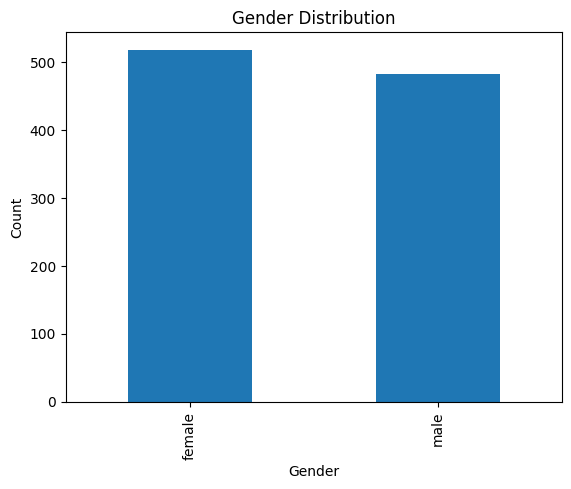

In [14]:
gender_count = df["gender"].value_counts()

gender_count.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

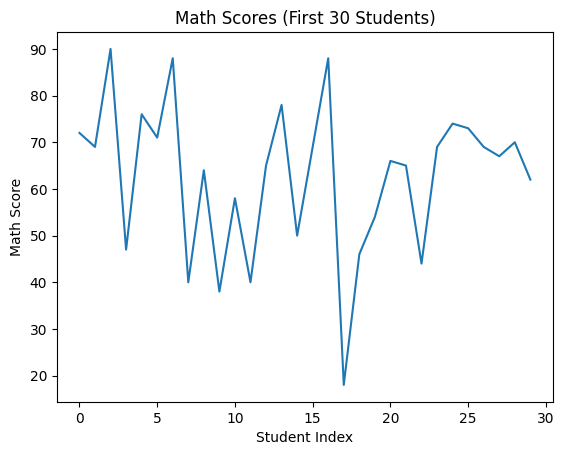

In [15]:
df["math score"].head(30).plot(kind="line")

plt.title("Math Scores (First 30 Students)")
plt.xlabel("Student Index")
plt.ylabel("Math Score")

plt.show()

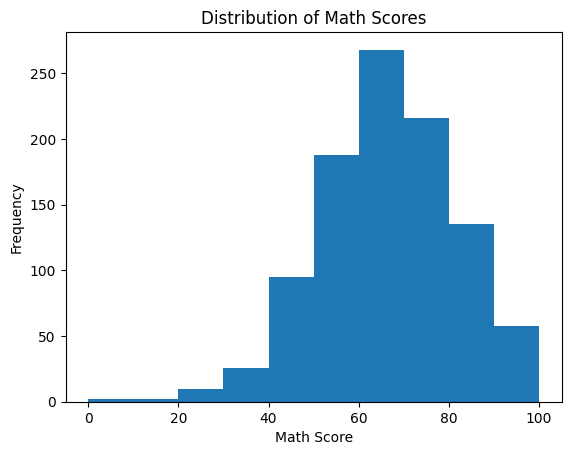

In [16]:
plt.hist(df["math score"], bins=10)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.show()

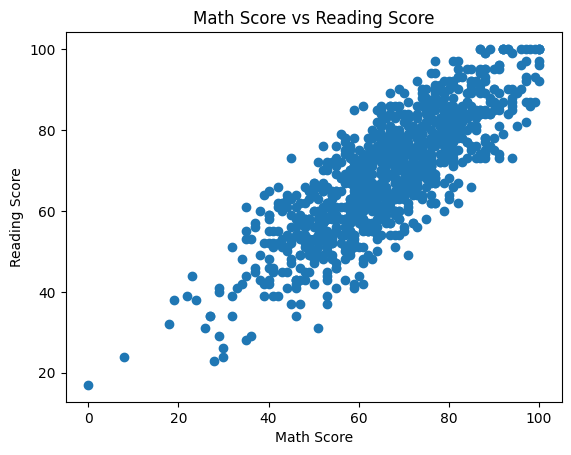

In [17]:
plt.scatter(df["math score"], df["reading score"])

plt.title("Math Score vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")

plt.show()

In [18]:
print("""
EDA SUMMARY

1. Dataset contains student academic performance records.
2. Missing values were checked.
3. Duplicate records were identified and removed.
4. Statistical measures such as mean, median, mode, variance, and standard deviation were calculated.
5. Correlation analysis was performed for numerical columns.
6. Visualizations were created using bar chart, line chart, histogram, and scatter plot.
7. Box plots were used to inspect possible outliers.
""")


EDA SUMMARY

1. Dataset contains student academic performance records.
2. Missing values were checked.
3. Duplicate records were identified and removed.
4. Statistical measures such as mean, median, mode, variance, and standard deviation were calculated.
5. Correlation analysis was performed for numerical columns.
6. Visualizations were created using bar chart, line chart, histogram, and scatter plot.
7. Box plots were used to inspect possible outliers.



In [19]:
# Detect and Treat Outliers using IQR

numeric_cols = df.select_dtypes(include=np.number)

for col in numeric_cols.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers treated successfully!")

Outliers treated successfully!
